In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
plt.rcParams.update({'font.size': 11})
df = pd.read_csv('../data/02_intermediate/adni_final_for_modeling.csv')

In [15]:
# Map Diagnosis
diagnosis_map = {1.0: 'CN', 2.0: 'MCI', 3.0: 'AD'}
df['Diagnosis_Label'] = df['DIAGNOSIS'].map(diagnosis_map)
df['Diagnosis_Label'] = pd.Categorical(df['Diagnosis_Label'], categories=['CN', 'MCI', 'AD'], ordered=True)

In [16]:
# Map Genotype
def categorize_genotype(g):
    if pd.isna(g): return 'Unknown'
    if '4' in g:
        return 'Risk Homozygous' if g == '4/4' else 'Risk Heterozygous'
    return 'Neutral'
df['Genotype_Risk'] = df['GENOTYPE'].apply(categorize_genotype)

In [17]:
biomarkers = [
    'pT217_F', 'AB42_F', 'AB40_F', 'NfL_Q', 'GFAP_Q', 
    'PHC_MEM', 'PHC_EXF', 'PHC_LAN', 
    'Left.Hippocampus_combat', 'Right.Hippocampus_combat', 
    'lh_entorhinal_volume_combat', 'rh_entorhinal_volume_combat', 
    'lh_entorhinal_thickness_combat', 'rh_entorhinal_thickness_combat', 
    'Left.Lateral.Ventricle_combat', 'Right.Lateral.Ventricle_combat', 
    'BrainSegVol_combat', 'EstimatedTotalIntraCranialVol_combat'
]

In [18]:
# Calculate mean +/- std for all biomarkers
summary_df = df.groupby('Diagnosis_Label')[biomarkers].agg(['mean', 'std']).transpose()
table_data = []
for feature in biomarkers:
    row = [feature]
    for diag in ['CN', 'MCI', 'AD']:
        # Access mean and std
        mean_val = summary_df.loc[(feature, 'mean'), diag]
        std_val = summary_df.loc[(feature, 'std'), diag]
        
        # Format based on magnitude
        if abs(mean_val) > 100:
            val_str = f"{mean_val:,.0f} ± {std_val:,.0f}"
        elif abs(mean_val) > 1:
            val_str = f"{mean_val:.2f} ± {std_val:.2f}"
        else:
            val_str = f"{mean_val:.3f} ± {std_val:.3f}"
        row.append(val_str)
    table_data.append(row)

    

/var/folders/5z/5t854vcx4d5_593ypf8qv0ph0000gn/T/ipykernel_21020/986759020.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = df.groupby('Diagnosis_Label')[biomarkers].agg(['mean', 'std']).transpose()


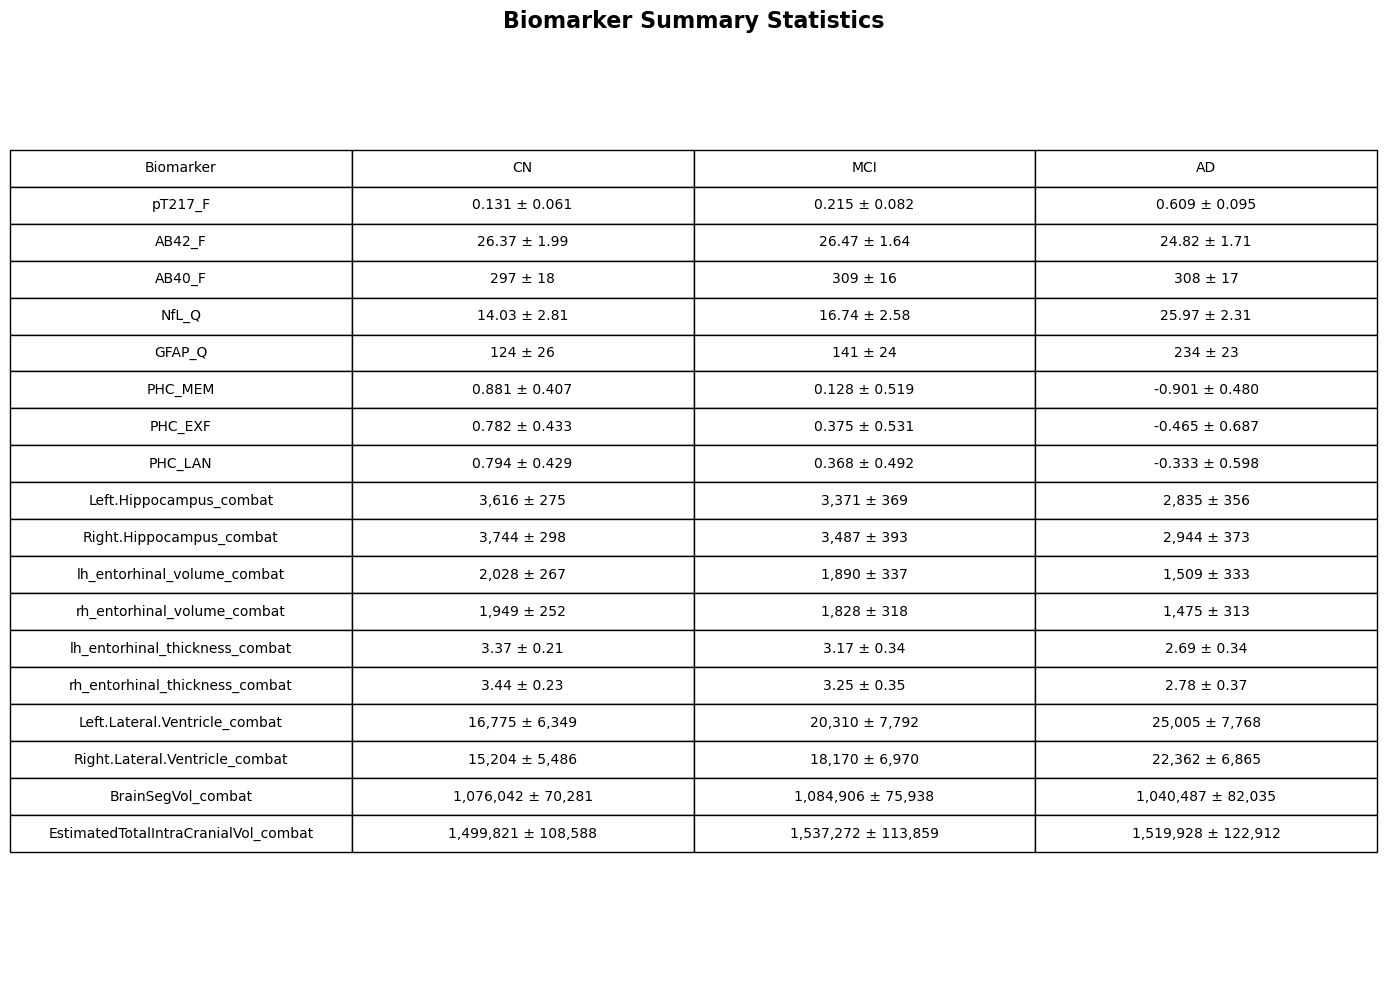

In [19]:
table_columns = ['Biomarker', 'CN', 'MCI', 'AD']

# Plot Table
fig, ax = plt.subplots(figsize=(14, len(biomarkers)*0.5 + 1))
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=table_columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
plt.title('Biomarker Summary Statistics', fontsize=16, weight='bold', y=0.99)
plt.tight_layout()
plt.show()

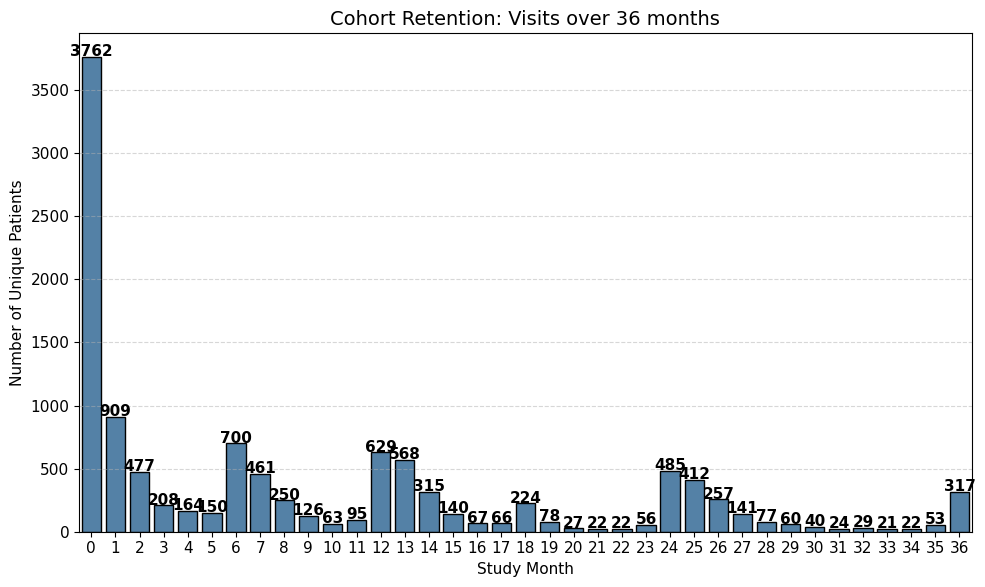

In [20]:
# Cohort retention
retention_data = df.groupby('Month')['RID'].nunique().reset_index()
retention_data.columns = ['Month', 'Patient_Count']

plt.figure(figsize=(10, 6))
# Bar chart showing counts at specific timepoints
sns.barplot(x='Month', y='Patient_Count', data=retention_data, color='steelblue', edgecolor='black')

# Add count labels
for index, row in retention_data.iterrows():
    plt.text(index, row.Patient_Count + 5, str(row.Patient_Count), color='black', ha="center", fontweight='bold')

plt.title('Cohort Retention: Visits over 36 months', fontsize=14)
plt.ylabel('Number of Unique Patients')
plt.xlabel('Study Month')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

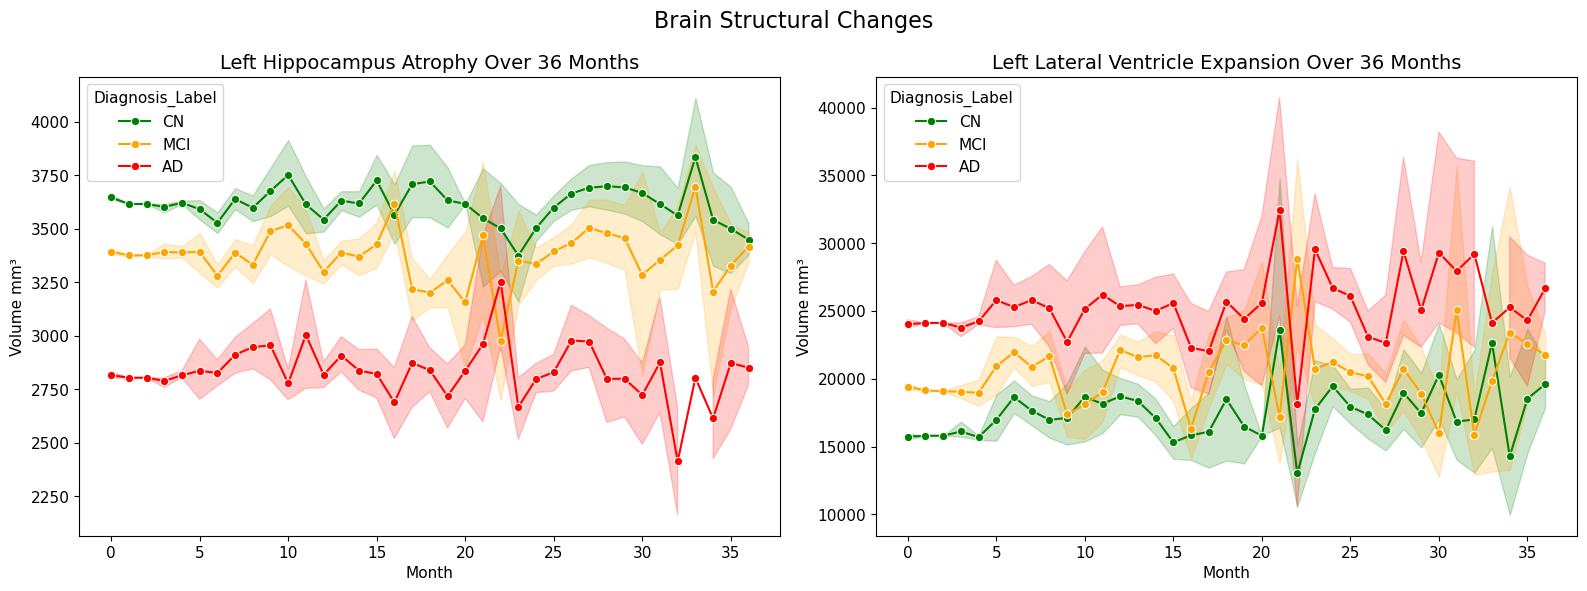

In [21]:
# Atrophy trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {'CN': 'green', 'MCI': 'orange', 'AD': 'red'}

# Hippocampus atrophy
sns.lineplot(x='Month', y='Left.Hippocampus_combat', hue='Diagnosis_Label', 
             data=df, palette=palette, marker='o', ax=axes[0])
axes[0].set_title('Left Hippocampus Atrophy Over 36 Months', fontsize=14)
axes[0].set_ylabel('Volume mm³')

# Subplot 2: Ventricles (Expansion)
sns.lineplot(x='Month', y='Left.Lateral.Ventricle_combat', hue='Diagnosis_Label', 
             data=df, palette=palette, marker='o', ax=axes[1])
axes[1].set_title('Left Lateral Ventricle Expansion Over 36 Months', fontsize=14)
axes[1].set_ylabel('Volume mm³')

plt.suptitle('Brain Structural Changes', fontsize=16)
plt.tight_layout()
plt.show()

/var/folders/5z/5t854vcx4d5_593ypf8qv0ph0000gn/T/ipykernel_21020/2681022456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pop_counts.index, y=pop_counts.values, ax=axes[0], palette=palette, edgecolor='black')
/opt/anaconda3/envs/bedrock/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/bedrock/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/bedrock/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


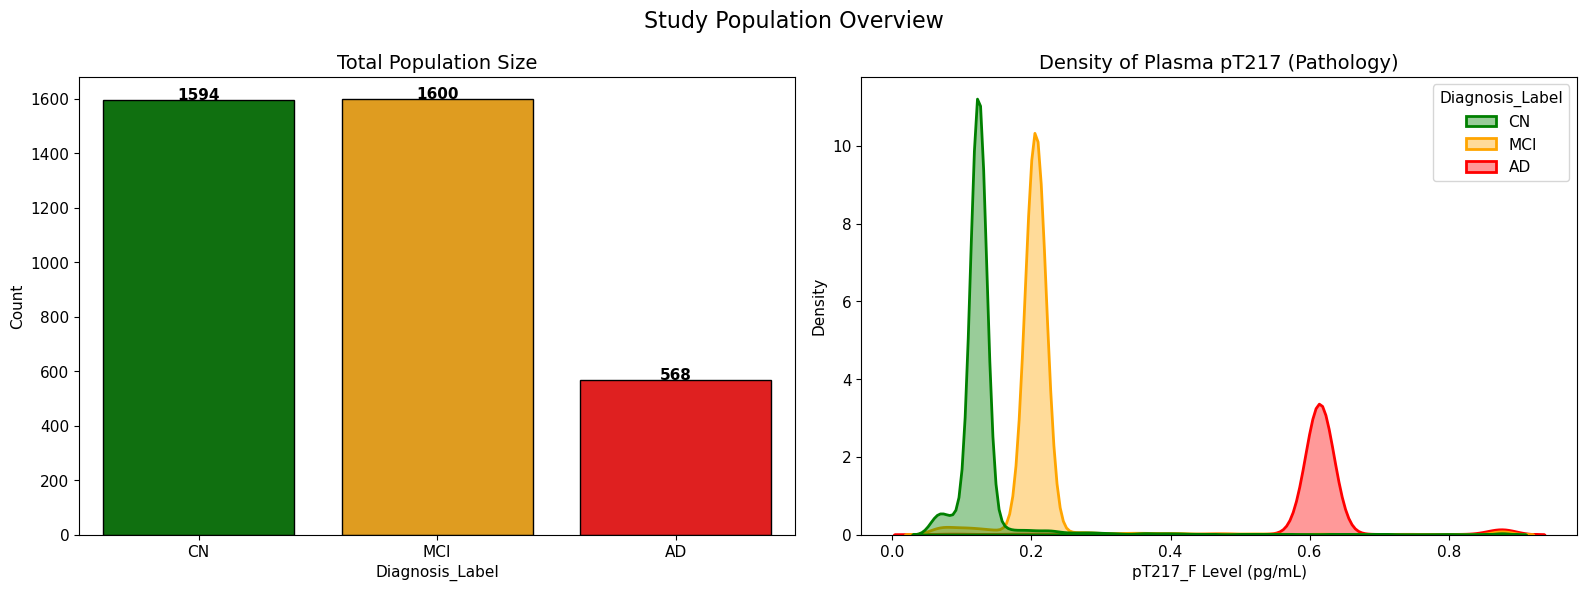

In [22]:
# Population size & density details
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Population count
pop_counts = df.drop_duplicates('RID')['Diagnosis_Label'].value_counts().sort_index()
sns.barplot(x=pop_counts.index, y=pop_counts.values, ax=axes[0], palette=palette, edgecolor='black')
axes[0].set_title('Total Population Size', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(pop_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Panel B: Density of pathology
sns.kdeplot(data=df, x='pT217_F', hue='Diagnosis_Label', fill=True, 
            palette=palette, alpha=0.4, linewidth=2, ax=axes[1])
axes[1].set_title('Density of Plasma pT217 (Pathology)', fontsize=14)
axes[1].set_xlabel('pT217_F Level (pg/mL)')

plt.suptitle('Study Population Overview', fontsize=16)
plt.tight_layout()
plt.show()

/var/folders/5z/5t854vcx4d5_593ypf8qv0ph0000gn/T/ipykernel_21020/3638103845.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/opt/anaconda3/envs/bedrock/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/bedrock/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/bedrock/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/bedrock/lib/python3.11/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/envs/bedrock

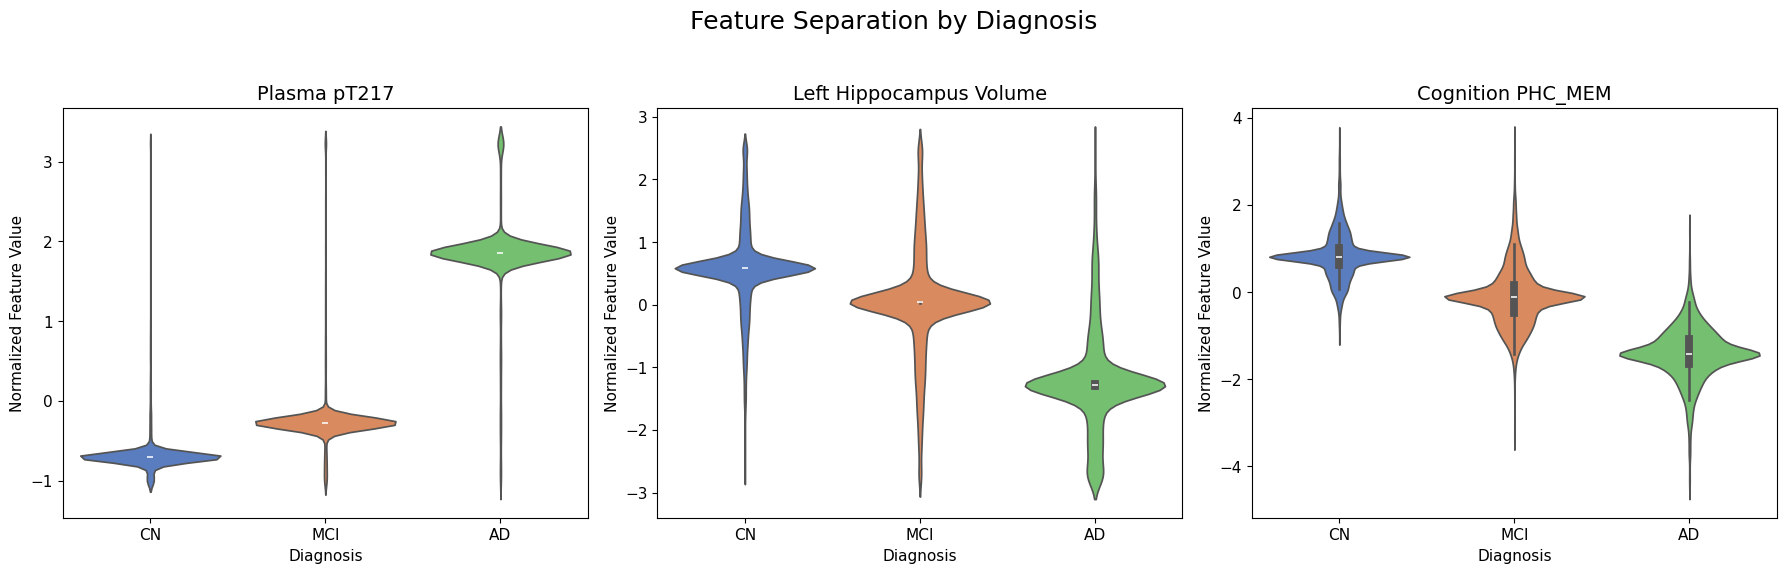

In [23]:
features_to_plot = ['pT217_F', 'Left.Hippocampus_combat', 'PHC_MEM']
feature_titles = ['Plasma pT217', 'Left Hippocampus Volume', 'Cognition PHC_MEM']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(features_to_plot):
    # Normalize for the axis label
    # Z score normalization: (x - mean) / std
    normalized_data = (df[col] - df[col].mean()) / df[col].std()
    
    sns.violinplot(
        x=df['Diagnosis_Label'], y=normalized_data, 
        order=['CN', 'MCI', 'AD'], ax=axes[i], palette='muted'
    )
    axes[i].set_title(feature_titles[i], fontsize=14)
    axes[i].set_ylabel('Normalized Feature Value')
    axes[i].set_xlabel('Diagnosis')

plt.suptitle('Feature Separation by Diagnosis', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

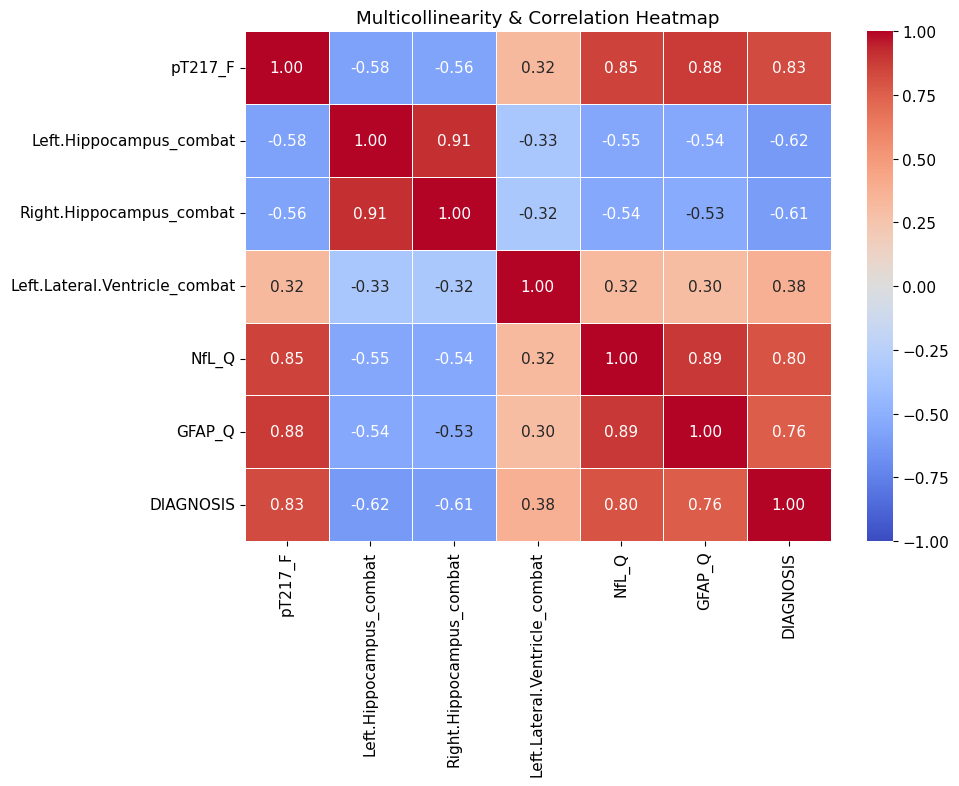

In [24]:
heatmap_cols = [
    'pT217_F', 'Left.Hippocampus_combat', 'Right.Hippocampus_combat', 
    'Left.Lateral.Ventricle_combat', 'NfL_Q', 'GFAP_Q', 'DIAGNOSIS'
]
correlation_matrix = df[heatmap_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
    vmin=-1, vmax=1, linewidths=0.5
)
plt.title('Multicollinearity & Correlation Heatmap')
plt.tight_layout()
plt.show()